# Sentiment Analysis

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize
from leia import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\ccsra\OneDrive\Documentos\A_TESE_TUDO\PROJETO\DF.csv", sep = ';')

## Extraindo os votos dos arquivos.txt da base de dados.csv

In [4]:
# 1. Defina uma função para carregar o texto
def carregar_texto_do_arquivo(caminho_no_csv):
    """
    Recebe o caminho da coluna 'voto' (ex: 'PASTA_DADOS/arquivo.txt'),
    encontra o nome do arquivo (ex: 'arquivo.txt') e lê seu conteúdo.
    """
    if pd.isna(caminho_no_csv):
        return None # Retorna nulo se o caminho estiver vazio
    
    # Esta é a parte chave:
    # O CSV diz 'PASTA_DADOS/ARQUIVOTAL.txt'
    # os.path.basename() pega apenas o nome do arquivo do caminho.
    nome_arquivo = os.path.basename(caminho_no_csv)
    
    try:
        # Tenta abrir o arquivo (assumindo que ele está na mesma pasta do seu notebook)
        with open(nome_arquivo, 'r', encoding='utf-8') as f:
            texto = f.read()
        return texto # Retorna o texto completo
        
    except FileNotFoundError:
        print(f"Aviso: Arquivo '{nome_arquivo}' não encontrado. Verifique o nome.")
        return f"ERRO: Arquivo '{nome_arquivo}' não encontrado"
    except Exception as e:
        print(f"Erro ao ler '{nome_arquivo}': {e}")
        return f"ERRO: {e}"

# 2. Crie a nova coluna 'texto_completo'
print("\nIniciando o carregamento dos textos do arquivo .txt para o DataFrame...")

# Verificamos se 'voto' existe no DataFrame 'df'
if 'voto' in df.columns:
    # O método 'apply' vai executar a função 'carregar_texto_do_arquivo'
    # para CADA linha da coluna 'voto'.
    df['texto_completo'] = df['voto'].apply(carregar_texto_do_arquivo)
    
    print("Carregamento concluído!")

    # 3. Verifique o resultado
    print("\nDataFrame 'dados' agora com a coluna 'texto_completo':")
    # (O .applymap abaixo é apenas para encurtar a exibição na tela)
    print(df[['id', 'voto', 'texto_completo']].head().map(lambda x: str(x)[:80] + '...' if isinstance(x, str) and len(x) > 80 else x))
      
else:
    print(f"\nERRO: A coluna 'voto' não foi encontrada no seu DataFrame 'dados'.")
    print("Colunas disponíveis:", df.columns.tolist())


Iniciando o carregamento dos textos do arquivo .txt para o DataFrame...
Carregamento concluído!

DataFrame 'dados' agora com a coluna 'texto_completo':
   id                         voto  \
0   1   PROJETO/AP_1025_FACHIN.txt   
1   2   PROJETO/AP_1025_MORAES.txt   
2   3  PROJETO/AP_1025_BARROSO.txt   
3   4   PROJETO/AP_1025_CARMEN.txt   
4   5   PROJETO/AP_1025_GILMAR.txt   

                                      texto_completo  
0  O SENHOR MINISTRO EDSON FACHIN (RELATOR): Conf...  
1  O SENHOR MINISTRO ALEXANDRE DE MORAES (REVISOR...  
2  O SENHOR MINISTRO LUÍS ROBERTO BARROSO - Obrig...  
3  A SENHORA MINISTRA CÁRMEN LÚCIA -\nPresidente,...  
4  O Senhor Ministro Gilmar Mendes: Trata-se de a...  


## Verificando as primeiras linhas de cada um dos votos com o texto bruto

In [21]:
# Itera sobre as 6 primeiras linhas do DataFrame para mostrar um resumo
for index, row in df.head(20).iterrows():
    print(f"--- Início do Voto ID: {row['id']} (Juiz: {row['juiz']}) ---")
    
    texto = row['texto_completo']
    
    # Verifica se o texto foi carregado corretamente
    if isinstance(texto, str) and not texto.startswith("ERRO"):
        # Divide o texto em linhas e pega as 6 primeiras
        primeiras_linhas = texto.split('\n')[:6]
        # Junta as linhas de volta em uma única string para exibição
        resumo_texto = '\n'.join(primeiras_linhas)
        print(resumo_texto)
        print("...\n")
    elif texto:
        # Se houver uma mensagem de erro, mostre-a
        print(texto)
        print("\n")
    else:
        # Caso o texto esteja vazio ou nulo
        print("Texto não disponível.\n")

--- Início do Voto ID: 1 (Juiz: Fachin) ---
O SENHOR MINISTRO EDSON FACHIN (RELATOR): Conforme
relatado, trata-se de Ação Penal deflagrada contra Fernando Affonso
Collor de Mello, Pedro Paulo Bergamaschi de Leoni Ramos e Luis Pereira
Duarte de Amorim, na qual a Procuradoria-Geral da República lhes
atribui a prática de crimes de corrupção passiva, lavagem de dinheiro e
organização criminosa.
...

--- Início do Voto ID: 2 (Juiz: Moraes) ---
O SENHOR MINISTRO ALEXANDRE DE MORAES (REVISOR): Trata-se
de Ação Penal instaurada para apurar a eventual prática das condutas
descritas no art. 317, §1º, (corrupção passiva), no art. 312 (peculato) e no
art. 324, §2º (violação de sigilo funcional qualificado), todos do Código
Penal, no art. 1º, §1º, I e §4º, da Lei n. 9.613/98 (lavagem de dinheiro), no
art. 2º, §3º e §4º, II, da Lei n. 12.850/13 (organização criminosa), no art. 2º,
...

--- Início do Voto ID: 3 (Juiz: Barroso) ---
O SENHOR MINISTRO LUÍS ROBERTO BARROSO - Obrigado,
Presidente. Muito b

## Verificando as últimas linhas de cada voto com o texto bruto

In [22]:
# Itera sobre as primeiras 20 linhas do DataFrame e mostra um resumo (últimas 5 linhas de cada voto)
for index, row in df.head(20).iterrows():
    print(f"--- Final do Voto ID: {row.get('id','?')} (Juiz: {row.get('juiz','?')}) ---")
    texto = row.get('texto_completo', '')
    # Verifica se o texto foi carregado corretamente
    if isinstance(texto, str) and not texto.startswith("ERRO"):
        # Divide o texto em linhas e pega as últimas 5
        linhas = texto.split('\n')
        ultimas_linhas = linhas[-5:] if len(linhas) >= 5 else linhas
        # Junta as linhas de volta em uma única string para exibição
        resumo_texto = '\n'.join(ultimas_linhas)
        print(resumo_texto)
        print("...\n")
    elif texto:
        # Se houver uma mensagem de erro, mostre-a
        print(texto)
        print("\n")
    else:
        # Caso o texto esteja vazio ou nulo
        print("Texto não disponível.\n")

--- Final do Voto ID: 1 (Juiz: Fachin) ---
das reprimendas impostas.
Após o trânsito em julgado da decisão colegiada, oficie-se ao
Tribunal Superior Eleitoral, para fins do art. 15, III, da Constituição
Federal.
É como voto.
...

--- Final do Voto ID: 2 (Juiz: Moraes) ---
15, III, da Constituição Federal;
b) lancem-se o nome dos réus no rol dos culpados;
c) expeçam-se guias de execução definitiva.
Custas pelos condenados (art. 804, do Código de Processo Penal).
É como voto.
...

--- Final do Voto ID: 3 (Juiz: Barroso) ---
pena, da dosimetria e do que trataremos mais à frente. A divergência é
pequena do ponto de vista jurídico, mas tem alguma relevância do ponto
de vista quantitativo na pena a ser aplicada.
Com essa única ressalva, estou aqui cumprimentando o eminente
Relator pelo primoroso trabalho e acompanhando Sua Excelência.
...

--- Final do Voto ID: 4 (Juiz: Carmen) ---
que estávamos diante não de uma associação nos termos do Código
Penal, mas verdadeiramente de uma organização c

## Configurações de visualização

## Processamento de texto e limpeza (Português)

In [23]:
class TextCleaner:
    """
    Responsável por todas as estratégias de limpeza de texto.
    """
    def __init__(self):
        self.stemmer = RSLPStemmer()
        self.stop_words = set(stopwords.words('portuguese'))
        
        # Stopwords específicas do contexto jurídico (ruído)
        termos_juridicos_irrelevantes = {
            'voto', 'senhor', 'ministro', 'presidente', 'excelencia', 'sessao',
            'turma', 'supremo', 'tribunal', 'federal', 'ata', 'publi', 'dj'
        }
        self.stop_words.update(termos_juridicos_irrelevantes)

    def limpeza_pesada(self, texto):
        """
        OBJETIVO: Gerar dados para modelagem de tópicos, nuvem de palavras ou clusterização.
        AÇÕES: Lowercase -> Remove Pontuação/Núm -> Remove Stopwords -> Stemming.
        """
        if not isinstance(texto, str): return ""
        
        # 1. Normalização
        texto = texto.lower()
        
        # 2. Remover caracteres especiais e números (mantém apenas letras)
        texto = re.sub(r'[^a-záàâãéèêíïóôõöúçñ\s]', '', texto)
        
        # 3. Tokenização
        tokens = word_tokenize(texto, language='portuguese')
        
        # 4. Filtragem e Stemming
        tokens_limpos = [
            self.stemmer.stem(t) for t in tokens 
            if t not in self.stop_words and len(t) > 2
        ]
        
        return " ".join(tokens_limpos)

    def limpeza_leve_sentimento(self, texto):
        """
        OBJETIVO: Preparar texto para o LeIA (Sentiment Analysis).
        AÇÕES: Preserva pontuação (!?), acentuação e estrutura de frases. Remove apenas sujeira de formatação.
        """
        if not isinstance(texto, str): return ""
        
        # Remove quebras de linha excessivas e espaços múltiplos
        texto = re.sub(r'\s+', ' ', texto).strip()
        return texto

## Aplicando a limpeza para Análise de Sentimentos

In [ ]:
# Instancia o limpador de texto
cleaner = TextCleaner()

# Aplica a limpeza leve (para análise de sentimento) na coluna 'texto_completo' e armazena o resultado em uma nova coluna.
df['texto_limpo_sentimento'] = df['texto_completo'].apply(cleaner.limpeza_leve_sentimento)

# Verificando as primeiras linhas para garantir que a limpeza foi aplicada
import textwrap

def visualizar_texto_limpo(df, n_linhas=6, wrap_width=100, max_wrapped_lines=6):
    print("--- VISUALIZAÇÃO ---\n")
    for _, row in df.head(n_linhas).iterrows():
        id_voto = row.get('id', '')
        juiz = row.get('juiz', '')
        texto = row.get('texto_limpo_sentimento', '') or ''
        print("="*80)
        print(f"ID: {id_voto} | Juiz: {juiz}")
        print("-"*80)
        if not texto.strip():
            print("⚠️  Texto vazio ou não processado corretamente\n")
            continue

        # Quebra o texto limpo em linhas visíveis
        wrapped = textwrap.wrap(texto, width=wrap_width)
        for i, linha in enumerate(wrapped[:max_wrapped_lines], start=1):
            print(f"{i}. {linha}")
        if len(wrapped) > max_wrapped_lines:
            print(f"... (+{len(wrapped) - max_wrapped_lines} linhas adicionais)")

        # Mostra também um preview contínuo (útil para confirmar limpeza)
        preview_chars = 300
        preview = texto[:preview_chars] + ("..." if len(texto) > preview_chars else "")
        print("\n--- Preview contínuo (primeiros %d chars) ---" % preview_chars)
        print(preview)
        print("\n")

# Chama a função
visualizar_texto_limpo(df, n_linhas=6, wrap_width=100, max_wrapped_lines=6)

## Analisador de Sentimentos

In [10]:
class SentimentAnalyzer:
    """
    Gerencia a análise de sentimentos e geração de gráficos.
    """
    def __init__(self):
        self.analyzer = SentimentIntensityAnalyzer()

# Função para analisar a evolução dos sentimentos dos votos
    def analisar_evolucao(self, texto, tamanho_chunk=3):
        """
        Divide o texto em blocos de sentenças e calcula o sentimento de cada bloco.
        """
        # Divide por sentenças (ponto final seguido de espaço e letra maiúscula ou fim de string)
        sentencas = re.split(r'(?<=[.!?])\s+(?=[A-Z])', texto)

        # Agrupa sentenças em chunks
        chunks = [" ".join(sentencas[i:i + tamanho_chunk]) for i in range(0, len(sentencas), tamanho_chunk)]

        scores = []
        for chunk in chunks:
            if len(chunk) > 10: # Ignora pedaços muito pequenos
                # 'compound' é a métrica normalizada [-1 a 1]
                score = self.analyzer.polarity_scores(chunk)['compound']
                scores.append(score)

        media_global = np.mean(scores) if scores else 0.0
        return media_global, scores

    def gerar_grafico(self, timeline, nome_juiz=None, caso=None, show=False, save=False, out_dir='graficos_output'):
        """Plota a evolução do sentimento para um único voto."""
        # Normaliza timeline para lista de floats
        if timeline is None:
            return None
        # Se a timeline veio como string (ex: leitura CSV), tentar converter
        if isinstance(timeline, str):
            try:
                import ast
                timeline = ast.literal_eval(timeline)
            except Exception:
                try:
                    timeline = [float(x.strip()) for x in timeline.split(',') if x.strip()!='']
                except Exception:
                    return None
        try:
            timeline_vals = [float(x) for x in timeline]
        except Exception:
            timeline_vals = []
            for x in timeline:
                try:
                    timeline_vals.append(float(x))
                except Exception:
                    continue
        if not timeline_vals:
            return None
        # Trata juiz/caso
        nome_juiz = str(nome_juiz or '')
        caso_val = '' if caso is None else str(caso).strip()
        if caso_val.lower() in ('nan','none'):
            caso_val = ''
        # Safe names para salvar arquivo
        safe_juiz = re.sub(r'[^\w\-_\. ]', '_', nome_juiz).strip().replace(' ', '_')
        safe_caso = re.sub(r'[^\w\-_\. ]', '_', caso_val).strip().replace(' ', '_')
        # Cria figura
        fig, ax = plt.subplots(figsize=(10, 4.5))
        x = list(range(1, len(timeline_vals) + 1))
        ax.plot(x, timeline_vals, color='#bdc3c7', alpha=0.6, label='Variação Local (Chunks)')
        window = max(1, len(timeline_vals) // 10)
        rolling_mean = pd.Series(timeline_vals).rolling(window=window, min_periods=1).mean()
        ax.plot(x, rolling_mean, color='#2980b9', linewidth=2.2, label='Tendência (Média Móvel)')
        ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
        if caso_val:
            titulo = f"Análise de Sentimento - {caso_val} - Min. {nome_juiz}"
        else:
            titulo = f"Análise de Sentimento - Min. {nome_juiz}"
        ax.set_title(titulo)
        ax.set_xlabel("Progresso do Discurso (Blocos de Texto)")
        ax.set_ylabel("Polaridade (-1: Negativo | +1: Positivo)")
        ax.set_ylim(-1.1, 1.1)
        ax.legend()
        fig.tight_layout()
        if show:
            from IPython.display import display
            display(fig)
        if save:
            os.makedirs(out_dir, exist_ok=True)
            filename = os.path.join(out_dir, f"caso_{safe_caso}_{safe_juiz}.png")
            fig.savefig(filename, dpi=100, bbox_inches='tight')
        plt.close(fig)

## Gerando os gráficos da evolução do sentimento para cada voto

Gerando gráficos para cada voto...


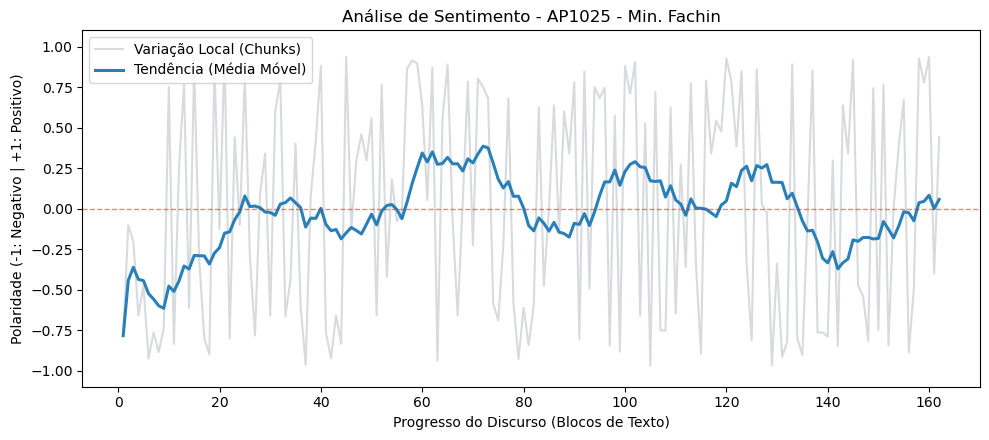

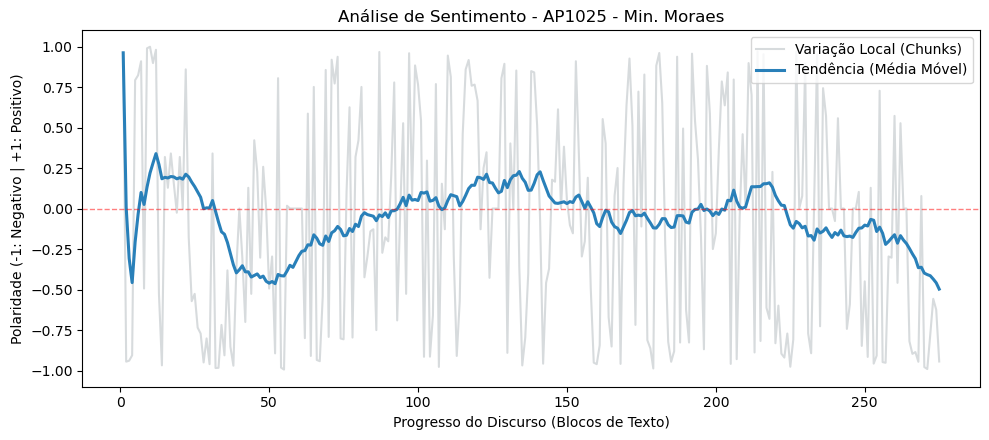

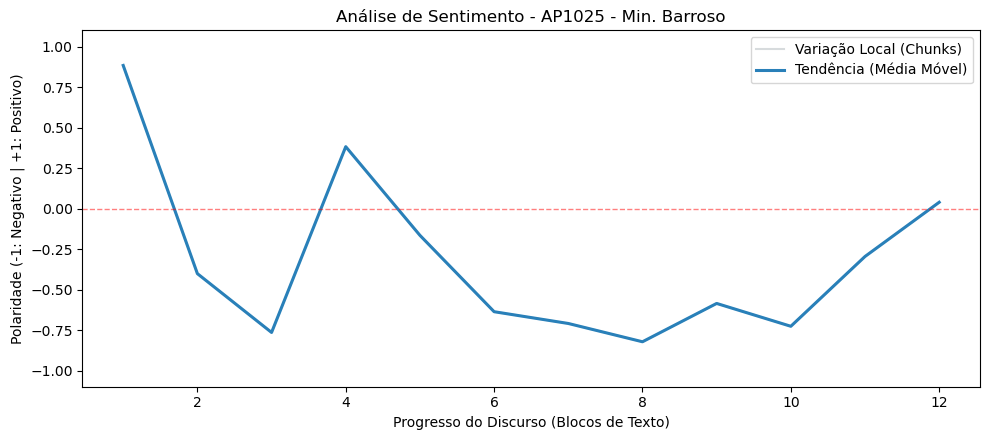

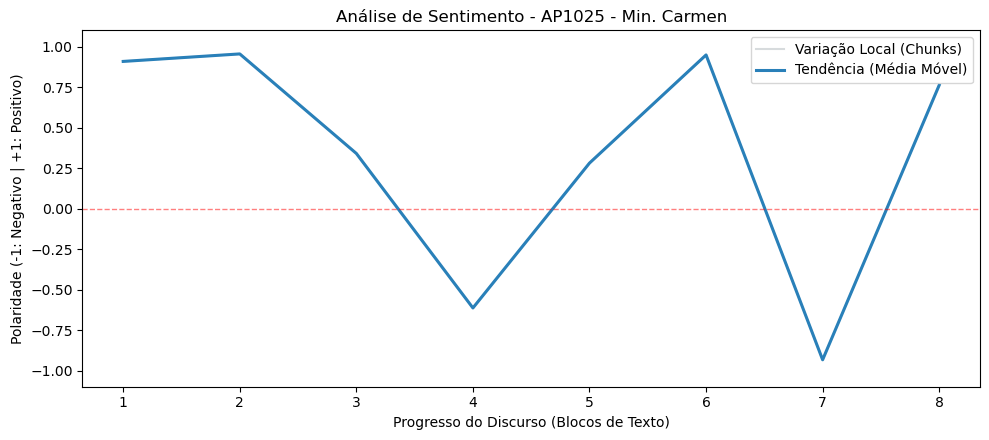

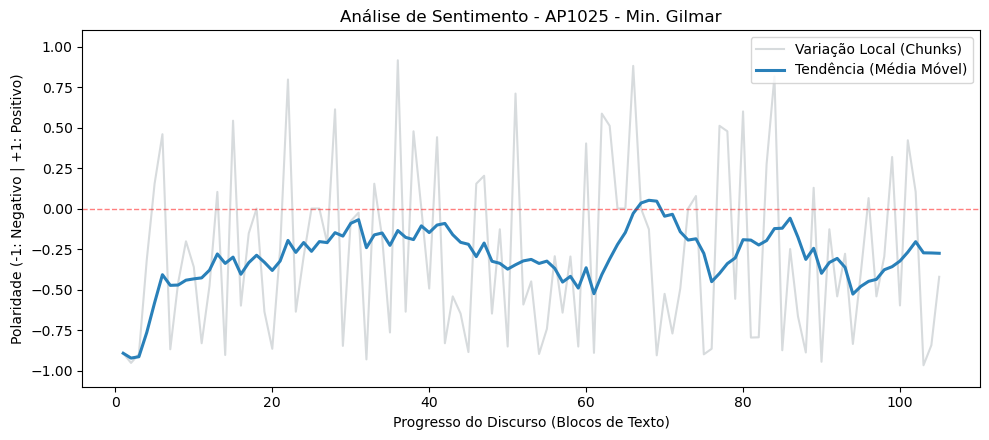

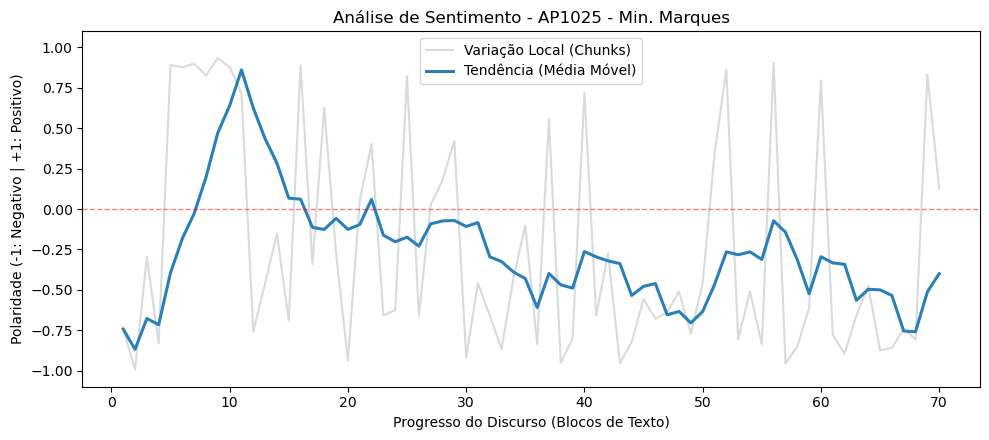

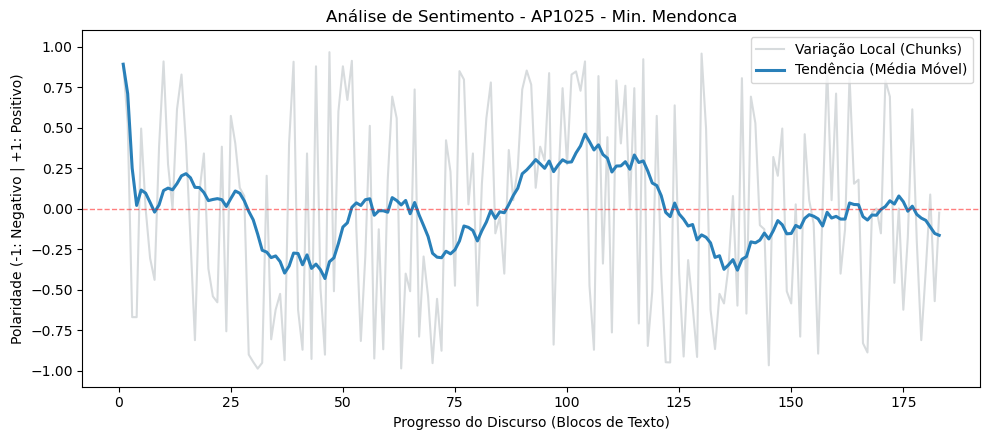

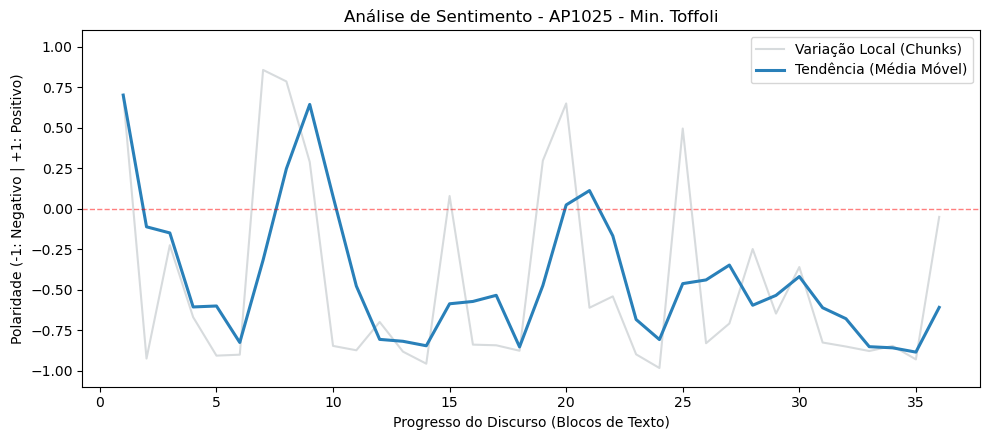

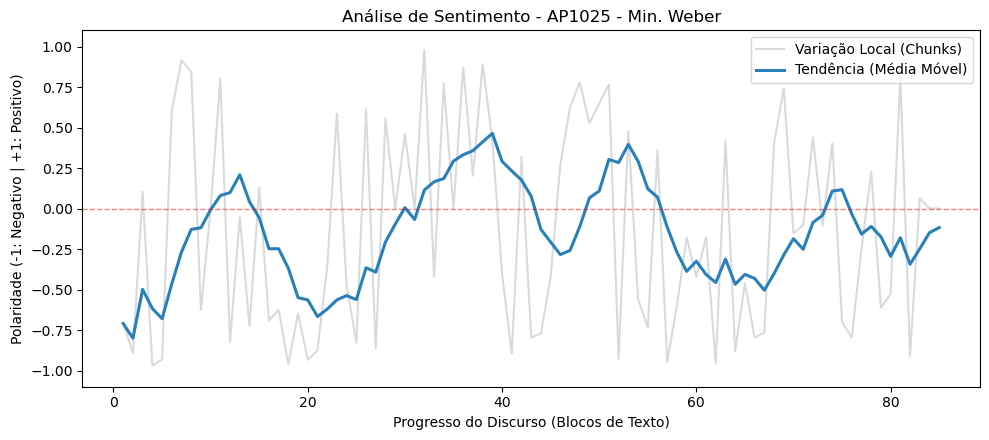

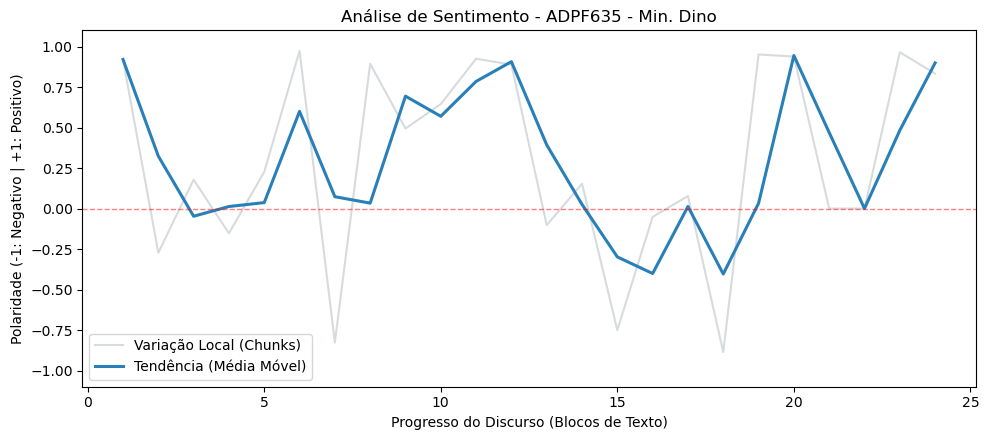

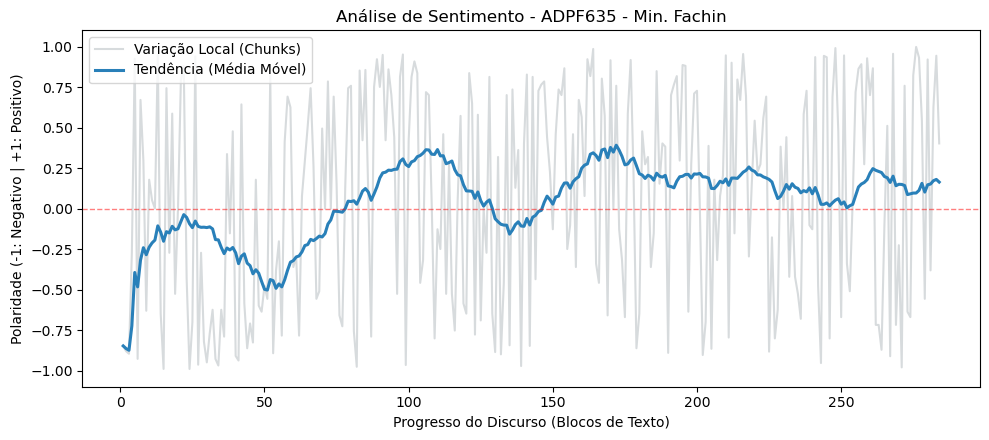

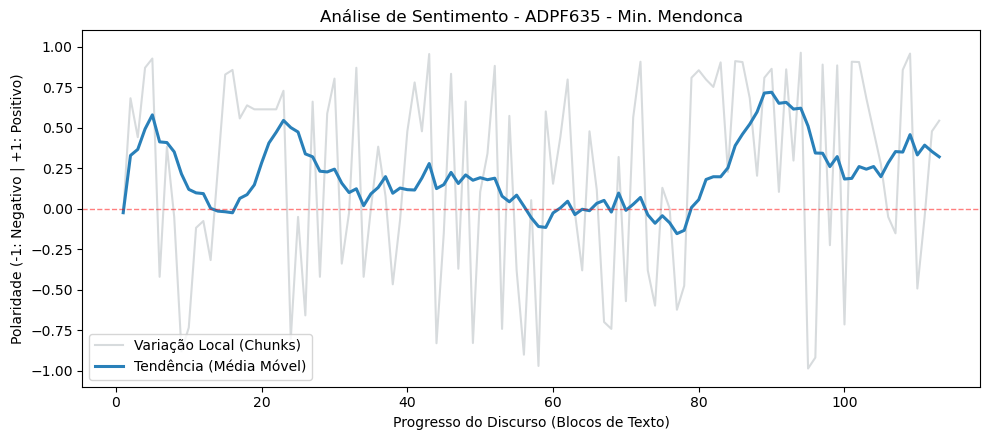

Processo concluído. Gráficos exibidos acima.


In [24]:
# Instancia o analisador de sentimentos
analyzer = SentimentAnalyzer()

print("Gerando gráficos para cada voto...")

# Itera sobre o DataFrame para gerar um gráfico por voto
for index, row in df.iterrows():
    timeline = row.get('timeline_chunks')
    
    # Gera o gráfico apenas se houver dados de sentimento (timeline)
    if timeline and len(timeline) > 0:
        analyzer.gerar_grafico(
            timeline=timeline,
            nome_juiz=row.get('juiz', 'N/A'),
            caso=row.get('caso', 'N/A'), 
            show=True
        )

print(f"Processo concluído. Gráficos exibidos acima.")

## Métricas da Análise de Sentimentos

In [19]:
# 1) Aplica analisar_evolucao() em 'texto_limpo_sentimento' e salva média + timeline
analyzer = SentimentAnalyzer()

medias = []
timelines = []

for idx, row in df.iterrows():
    texto = row.get('texto_limpo_sentimento', '') or ''
    if isinstance(texto, str) and texto.strip():
        media, timeline = analyzer.analisar_evolucao(texto)
        medias.append(media)
        timelines.append(timeline)
    else:
        medias.append(np.nan)
        timelines.append([])

# ============================================================================
# MÉTRICAS DE ANÁLISE DE SENTIMENTO - EXPLICAÇÃO DETALHADA
# ============================================================================
# 
# SCORE_MEDIA (score_media):
#   - Descrição: Sentimento médio GLOBAL de todo o voto
#   - Tipo: Float [-1 a +1]
#   - Interpretação:
#     * -1.0 = Muito negativo
#     * 0.0 = Neutro
#     * +1.0 = Muito positivo
#   - Uso: Para análises agregadas e comparações rápidas entre votos
#   - Exemplo: score_media = 0.15 significa que o voto tem sentimento levemente positivo
#
# TIMELINE_CHUNKS (timeline_chunks):
#   - Descrição: Lista completa de scores de sentimento para CADA bloco de texto
#   - Tipo: List[float] com múltiplos valores
#   - Explicação: O voto é dividido em blocos (chunks) de sentenças, e cada bloco
#     tem seu próprio score de sentimento. Essa timeline mostra a EVOLUÇÃO do 
#     sentimento ao longo do discurso
#   - Uso: Para criar gráficos de evolução temporal e análises detalhadas
#   - Exemplo: timeline = [-0.5, -0.2, 0.1, 0.3, 0.2] mostra sentimento crescendo
#
# TIMELINE_LEN (timeline_len):
#   - Descrição: Número TOTAL de blocos (chunks) em que o voto foi dividido
#   - Tipo: Integer (quantidade de chunks)
#   - Explicação: Indica quantos blocos o método analisar_evolucao() criou
#   - Uso: Para entender a granularidade da análise (votos longos = mais chunks)
#   - Exemplo: timeline_len = 150 significa que o voto foi dividido em 150 blocos
#
# TIMELINE_PREVIEW (timeline_preview_str):
#   - Descrição: Amostra dos PRIMEIROS 5 valores de sentimento + contagem de blocos restantes
#   - Tipo: String formatada para exibição
#   - Explicação: Mostra um "resumo" dos primeiros 5 chunks em formato legível na tabela
#   - Uso: Para visualização rápida na tabela sem sobrecarregar a tela
#   - Exemplo: "0.15, -0.45, 0.22, 0.88, -0.10 ...(+145)" = primeiros 5 scores + mais 145 blocos
#
# AMPLITUDE_SENTIMENTO (amplitude_sentimento):
#   - Descrição: Diferença entre o score MÁXIMO e o score MÍNIMO da timeline
#   - Tipo: Float [0 a 2.0]
#   - Fórmula: max(timeline) - min(timeline)
#   - Interpretação:
#     * Amplitude ≈ 0 = Voto com sentimento ESTÁVEL/CONSISTENTE (pouca variação)
#     * Amplitude = 1.0 = Voto com sentimento MUITO VARIÁVEL (vai de -1 a +1)
#     * Amplitude ≈ 2.0 = Voto com MÁXIMA variabilidade (vai de -1 até +1)
#   - Uso: Identifica votos que mudam de opinião/tom ao longo do discurso
#   - Importância: Tão importante quanto score_media! Complementa a análise.
#   - Exemplo: score_media=0.1 + amplitude=1.8 = voto próximo de neutro mas MUITO instável
#            : score_media=0.1 + amplitude=0.2 = voto próximo de neutro e COERENTE/ESTÁVEL
#
# ============================================================================

df['score_media'] = medias
df['timeline_chunks'] = timelines

print("Pronto: colunas 'score_media' e 'timeline_chunks' adicionadas ao DataFrame.")


# Gera uma pré-visualização curta dos primeiros 5 chunks para evitar saída muito grande
timeline_preview = [tl[:5] if isinstance(tl, list) else [] for tl in timelines]

# Converte a pré-visualização em string curta para exibição segura
# (lista de floats → string formatada com 2 casas decimais)
timeline_preview_str = [(", ".join([f"{s:.2f}" if isinstance(s, float) else str(s) for s in tl]) + (f" ...(+{len(tl)-5})" if len(tl) > 5 else "")) if tl else "" for tl in timeline_preview]

# Calcula o comprimento de cada timeline (quantos chunks cada voto tem)
timeline_len = [len(tl) if isinstance(tl, list) else 0 for tl in timelines]

# Calcula a AMPLITUDE (diferença entre máximo e mínimo) da timeline
# Métrica importante que indica a variabilidade do sentimento ao longo do voto
amplitude_sentimento = []
for tl in timelines:
    if isinstance(tl, list) and len(tl) > 0:
        amplitude = max(tl) - min(tl)
        amplitude_sentimento.append(amplitude)
    else:
        amplitude_sentimento.append(np.nan)

df['timeline_preview'] = timeline_preview_str
df['timeline_len'] = timeline_len
df['amplitude_sentimento'] = amplitude_sentimento

# Mostra apenas as colunas geradas para verificação (primeiras 10 linhas)
print("Pronto: colunas 'score_media' e 'timeline_chunks' adicionadas ao DataFrame.")
print("Abaixo uma verificação resumida (id, juiz, score_media, amplitude_sentimento, timeline_len, timeline_preview):\n")
print(df[['id', 'juiz', 'score_media', 'amplitude_sentimento', 'timeline_len', 'timeline_preview']].head(10).to_string(index=False))

Pronto: colunas 'score_media' e 'timeline_chunks' adicionadas ao DataFrame.
Pronto: colunas 'score_media' e 'timeline_chunks' adicionadas ao DataFrame.
Abaixo uma verificação resumida (id, juiz, score_media, amplitude_sentimento, timeline_len, timeline_preview):

 id     juiz  score_media  amplitude_sentimento  timeline_len                  timeline_preview
  1   Fachin     0.002681                1.9323           162 -0.78, -0.10, -0.20, -0.66, -0.48
  2   Moraes    -0.085601                1.9927           275   0.96, -0.95, -0.94, -0.91, 0.79
  3  Barroso    -0.317208                1.7057            12   0.88, -0.40, -0.77, 0.38, -0.17
  4   Carmen     0.330638                1.8881             8     0.91, 0.95, 0.34, -0.61, 0.28
  5   Gilmar    -0.279161                1.8829           105  -0.89, -0.95, -0.90, -0.32, 0.15
  6  Marques    -0.240817                1.9291            70  -0.74, -0.99, -0.30, -0.83, 0.89
  7 Mendonca    -0.031405                1.9535           183   